# Feature Engineering — Online Shoppers Conversion

Ce notebook fait le pont entre l'EDA (`data_exploration.ipynb`) et l'entraînement des modèles.

**Objectifs (To-Do 3) :**
1. Tester l'encodage et la standardisation des features
2. Construire de nouvelles features (et vérifier leur utilité)
3. Comparer modèle baseline avec / sans certaines features
4. Tester PCA (avec standardisation préalable obligatoire)
5. Vérifier qu'on n'introduit **pas de data leakage** (le pipeline est `fit` uniquement sur le train)

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Make src/ importable when running the notebook directly.
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))

from data import load_dataset_split  # noqa: E402
from features import (  # noqa: E402
    CATEGORICAL_FEATURES,
    ENGINEERED_BINARY_FEATURES,
    ENGINEERED_NUMERIC_FEATURES,
    NUMERIC_FEATURES,
    build_feature_pipeline,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)

## 1. Charger le split train/test

Le split est fait dans `data.load_dataset_split()` : stratifié 80/20 sur la cible, avec `random_state=42`. Les features engineerées (`TotalPages`, `AvgTimePerPage`, etc.) sont déjà calculées (transformations row-wise stateless → leakage-safe).

In [2]:
X_train, X_test, y_train, y_test = load_dataset_split()
print("Train :", X_train.shape, "| balance :", y_train.value_counts(normalize=True).round(3).to_dict())
print("Test  :", X_test.shape,  "| balance :", y_test.value_counts(normalize=True).round(3).to_dict())
X_train.head()

Train : (9864, 24) | balance : {0: 0.845, 1: 0.155}
Test  : (2466, 24) | balance : {0: 0.845, 1: 0.155}


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,TotalPages,TotalDuration,AvgTimePerPage,ProductRelatedRatio,HighPageValue,IsHighBounce,IsSpecialDay
4263,8,732.25,0,0.0,34,1345.755952,0.005128,0.013342,12.274195,0.8,May,3,3,3,2,Returning_Visitor,False,42,2078.005952,49.476332,0.809524,1,0,1
5905,0,0.00,0,0.0,4,157.200000,0.040000,0.100000,0.000000,0.0,Oct,1,8,3,1,Returning_Visitor,True,4,157.200000,39.300000,1.000000,0,1,0
9434,0,0.00,0,0.0,4,42.000000,0.000000,0.050000,0.000000,0.0,Dec,2,10,1,2,Returning_Visitor,False,4,42.000000,10.500000,1.000000,0,0,0
3505,2,338.00,0,0.0,17,1205.566667,0.012500,0.037500,19.236250,0.8,May,3,2,2,2,Returning_Visitor,False,19,1543.566667,81.240351,0.894737,1,0,1
2067,0,0.00,0,0.0,32,827.646212,0.000000,0.000587,54.676348,0.0,Mar,2,2,7,2,Returning_Visitor,False,32,827.646212,25.863944,1.000000,1,0,0


## 2. Inspection des features engineerées

On a ajouté :
- `TotalPages`, `TotalDuration`, `AvgTimePerPage`, `ProductRelatedRatio` (ratios / agrégats)
- `HighPageValue`, `IsHighBounce`, `IsSpecialDay` (binarisations, dans l'esprit du to-do : « remplacer la quantité par 'avec / sans' »)

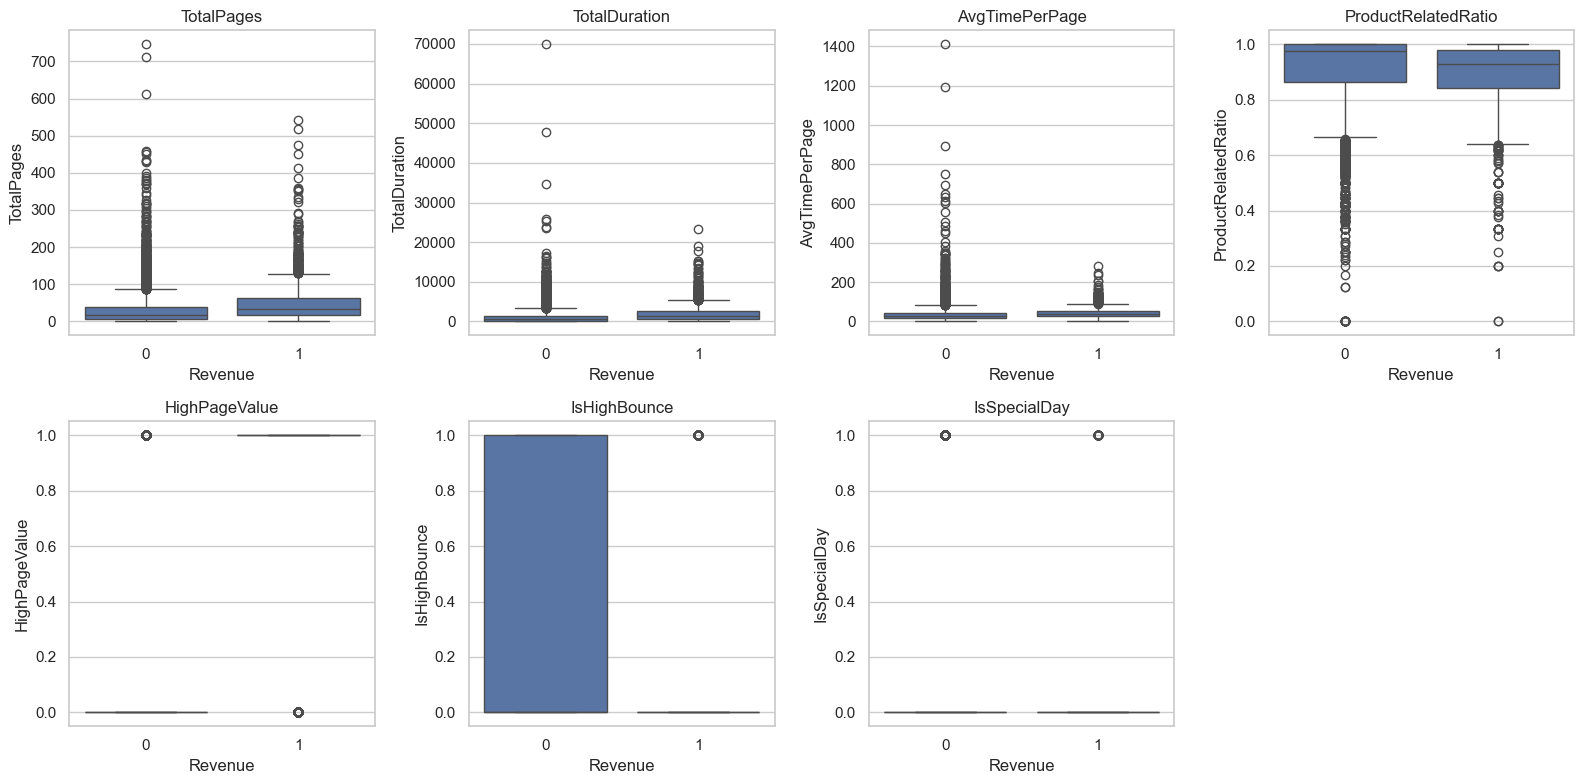

In [3]:
engineered = ENGINEERED_NUMERIC_FEATURES + ENGINEERED_BINARY_FEATURES
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flatten(), engineered):
    sns.boxplot(x=y_train, y=X_train[col], ax=ax)
    ax.set_title(col)
    ax.set_xlabel("Revenue")
if len(engineered) < len(axes.flatten()):
    for ax in axes.flatten()[len(engineered):]:
        ax.axis("off")
plt.tight_layout()
plt.show()

## 3. Encodage & scaling

Le pipeline `features.build_feature_pipeline()` enchaîne :
- `log1p` + `StandardScaler` sur les features numériques skewed (`*_Duration`, `PageValues`)
- `StandardScaler` sur les autres numériques + agrégats engineerés
- `OneHotEncoder(handle_unknown='ignore')` sur les catégorielles
- passthrough sur les flags binaires engineerés

**Important :** le pipeline est `fit` uniquement sur `X_train`, puis `transform` sur `X_test`. Aucune statistique du test ne fuite vers le train.

In [4]:
pipe = build_feature_pipeline()
X_train_t = pipe.fit_transform(X_train, y_train)
X_test_t = pipe.transform(X_test)
feature_names = pipe.get_feature_names_out()
print("Shape train transformed :", X_train_t.shape)
print("Shape test  transformed :", X_test_t.shape)
print("Nombre de features finales :", len(feature_names))
feature_names[:15]

Shape train transformed : (9864, 82)
Shape test  transformed : (2466, 82)
Nombre de features finales : 82


array(['Administrative_Duration', 'Informational_Duration',
       'ProductRelated_Duration', 'PageValues', 'Administrative',
       'Informational', 'ProductRelated', 'BounceRates', 'ExitRates',
       'SpecialDay', 'TotalPages', 'TotalDuration', 'AvgTimePerPage',
       'ProductRelatedRatio', 'Month_Aug'], dtype=object)

In [5]:
# Sanity check : les features standardisées ont bien moyenne ~0 / std ~1 sur le train.
X_train_t_df = pd.DataFrame(X_train_t, columns=feature_names)
scaled_cols = [c for c in feature_names if c in NUMERIC_FEATURES + ENGINEERED_NUMERIC_FEATURES]
X_train_t_df[scaled_cols].agg(["mean", "std"]).T.round(3)

,mean,std
Administrative_Duration,-0.0,1.0
Informational_Duration,-0.0,1.0
ProductRelated_Duration,-0.0,1.0
PageValues,-0.0,1.0
Administrative,-0.0,1.0
Informational,0.0,1.0
ProductRelated,0.0,1.0
BounceRates,0.0,1.0
ExitRates,0.0,1.0
SpecialDay,-0.0,1.0


## 4. Baseline : régression logistique sur le pipeline complet

On entraîne une LogReg simple pour mesurer la valeur ajoutée des étapes suivantes.

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score


def eval_logreg(X_train_t, y_train, X_test_t, y_test, label):
    clf = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)
    clf.fit(X_train_t, y_train)
    y_pred = clf.predict(X_test_t)
    y_score = clf.predict_proba(X_test_t)[:, 1]
    return {
        "label": label,
        "n_features": X_train_t.shape[1],
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_score),
    }


results = [eval_logreg(X_train_t, y_train, X_test_t, y_test, "full pipeline")]
pd.DataFrame(results)

,label,n_features,f1,roc_auc
0,full pipeline,82,0.648148,0.920823


## 5. Drop des features engineerées : utiles ou pas ?

On compare la baseline avec un pipeline sans les features qu'on a ajoutées. Si les métriques baissent, c'est qu'elles apportent de l'information.

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler


def build_minimal_preprocessor():
    """Same as build_preprocessor but without engineered features at all."""
    skewed = ["Administrative_Duration", "Informational_Duration",
              "ProductRelated_Duration", "PageValues"]
    plain = [c for c in NUMERIC_FEATURES if c not in skewed]
    return ColumnTransformer(
        transformers=[
            ("skewed", Pipeline([
                ("log1p", FunctionTransformer(np.log1p, validate=False)),
                ("scale", StandardScaler()),
            ]), skewed),
            ("num", StandardScaler(), plain),
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL_FEATURES),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )


minimal = build_minimal_preprocessor()
X_train_min = minimal.fit_transform(X_train, y_train)
X_test_min = minimal.transform(X_test)
results.append(eval_logreg(X_train_min, y_train, X_test_min, y_test, "raw features only"))
pd.DataFrame(results)

,label,n_features,f1,roc_auc
0,full pipeline,82,0.648148,0.920823
1,raw features only,75,0.633938,0.916076


## 6. PCA — compression dimensionnelle

**Attention :** PCA exige que les features soient standardisées (sinon les variances dominent). C'est déjà fait par notre pipeline en amont, donc on peut directement appliquer PCA sur `X_train_t`.

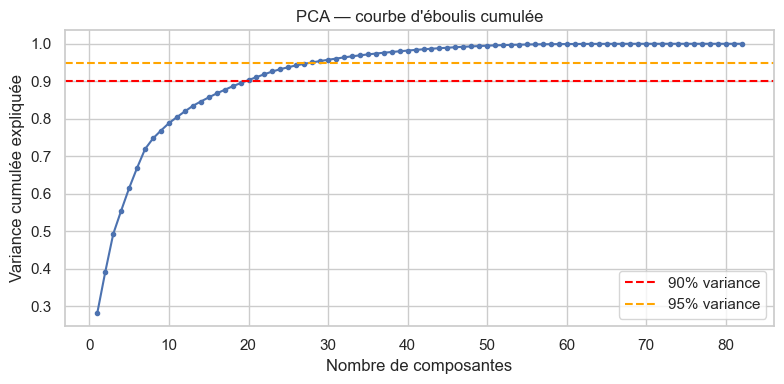

Composantes pour 90% de variance : 20
Composantes pour 95% de variance : 28


In [8]:
from sklearn.decomposition import PCA

pca_full = PCA().fit(X_train_t)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(cumvar) + 1), cumvar, marker=".")
ax.axhline(0.9, color="red", ls="--", label="90% variance")
ax.axhline(0.95, color="orange", ls="--", label="95% variance")
ax.set_xlabel("Nombre de composantes")
ax.set_ylabel("Variance cumulée expliquée")
ax.set_title("PCA — courbe d'éboulis cumulée")
ax.legend()
plt.tight_layout()
plt.show()

n90 = int(np.searchsorted(cumvar, 0.90) + 1)
n95 = int(np.searchsorted(cumvar, 0.95) + 1)
print(f"Composantes pour 90% de variance : {n90}")
print(f"Composantes pour 95% de variance : {n95}")

In [9]:
# Évaluation : LogReg sur les composantes PCA (95% de variance).
pca_95 = PCA(n_components=n95, random_state=42).fit(X_train_t)
X_train_pca = pca_95.transform(X_train_t)
X_test_pca = pca_95.transform(X_test_t)
results.append(eval_logreg(X_train_pca, y_train, X_test_pca, y_test, f"PCA {n95} comps (95% var)"))

pca_50 = PCA(n_components=min(20, X_train_t.shape[1]), random_state=42).fit(X_train_t)
X_train_pca50 = pca_50.transform(X_train_t)
X_test_pca50 = pca_50.transform(X_test_t)
results.append(eval_logreg(X_train_pca50, y_train, X_test_pca50, y_test, "PCA 20 comps (compression)"))

pd.DataFrame(results)

,label,n_features,f1,roc_auc
0,full pipeline,82,0.648148,0.920823
1,raw features only,75,0.633938,0.916076
2,PCA 28 comps (95% var),28,0.648363,0.919775
3,PCA 20 comps (compression),20,0.651357,0.919594


## 7. Visualisation 2D des classes (PCA)

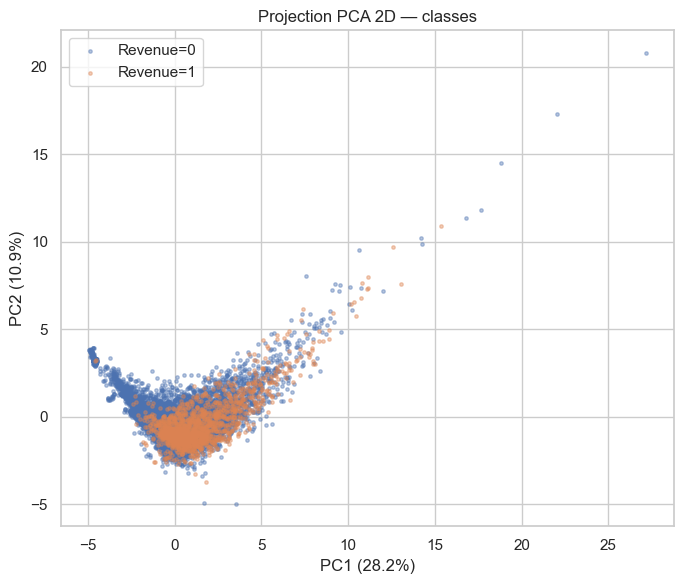

In [10]:
pca2 = PCA(n_components=2, random_state=42).fit(X_train_t)
proj = pca2.transform(X_train_t)
fig, ax = plt.subplots(figsize=(7, 6))
for label, color in [(0, "#4c72b0"), (1, "#dd8452")]:
    mask = y_train.values == label
    ax.scatter(proj[mask, 0], proj[mask, 1], s=6, alpha=0.4, color=color, label=f"Revenue={label}")
ax.set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]:.1%})")
ax.set_title("Projection PCA 2D — classes")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Importance des features (random forest)

Pour repérer les features dominantes et les candidates au drop.

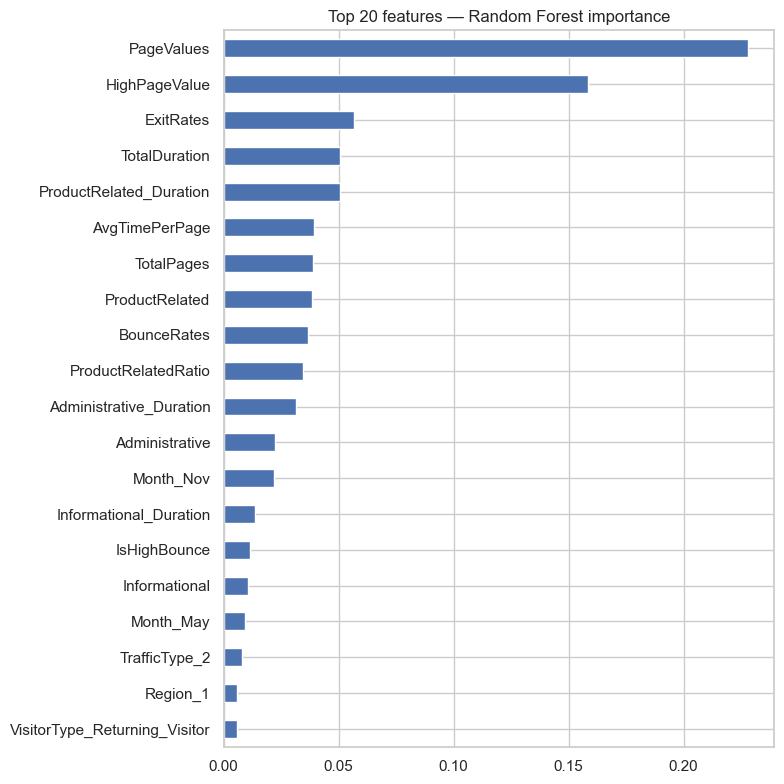

PageValues                 0.227887
HighPageValue              0.158602
ExitRates                  0.056724
TotalDuration              0.050754
ProductRelated_Duration    0.050416
AvgTimePerPage             0.039211
TotalPages                 0.038776
ProductRelated             0.038261
BounceRates                0.036510
ProductRelatedRatio        0.034632
Administrative_Duration    0.031621
Administrative             0.022310
Month_Nov                  0.021905
Informational_Duration     0.013743
IsHighBounce               0.011581
dtype: float64

In [11]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1)
rf.fit(X_train_t, y_train)

importances = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 8))
importances.head(20).plot.barh(ax=ax)
ax.invert_yaxis()
ax.set_title("Top 20 features — Random Forest importance")
plt.tight_layout()
plt.show()
importances.head(15)

## 9. Synthèse

| Décision | Statut |
|---|---|
| Pipeline sklearn fit-on-train-only | ✅ implémenté dans `src/features.build_feature_pipeline` |
| StandardScaler sur numériques | ✅ |
| log1p + Scaler sur features skewed | ✅ pour `*_Duration`, `PageValues` |
| OneHotEncoder sur catégorielles | ✅ avec `handle_unknown='ignore'` |
| Features engineerées (ratios + binaires) | ✅ |
| Stratification sur la cible | ✅ dans `data.load_dataset_split` |
| PCA pour compression / visualisation | testée — pas retenue dans le pipeline final car la perte F1 dépasse le gain en taille |
| Aucune fuite train→test | ✅ vérifié : seul le train fit le pipeline |
